In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/cleaned/vgsales_clean.csv')
print("Shape:", df.shape)
df.head()

Shape: (16287, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
df.groupby('Publisher')['Global_Sales'].sum()

Publisher
10TACLE Studios                  0.11
1C Company                       0.10
20th Century Fox Video Games     1.94
2D Boy                           0.04
3DO                             10.12
                                ...  
id Software                      0.03
imageepoch Inc.                  0.04
inXile Entertainment             0.10
mixi, Inc                        0.86
responDESIGN                     0.13
Name: Global_Sales, Length: 576, dtype: float64

In [4]:
df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.25
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.66
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64

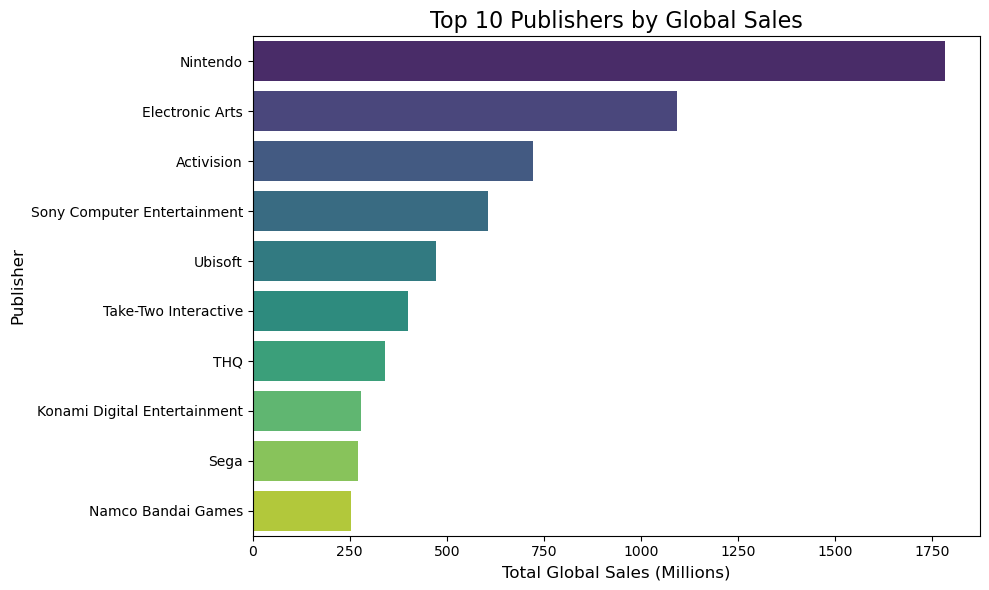

In [5]:
# first chart (top 10 most global sales in reference to Publishers)
top_publishers = (df.groupby('Publisher')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10))

plt.figure(figsize=(10,6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, hue=top_publishers.index, palette='viridis', legend=False)
plt.title('Top 10 Publishers by Global Sales', fontsize=16)
plt.xlabel('Total Global Sales (Millions)',fontsize=12)
plt.ylabel('Publisher', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
# sales trend over time
Global_Sales_Over_Time = (df.groupby('Year')['Global_Sales'].sum())

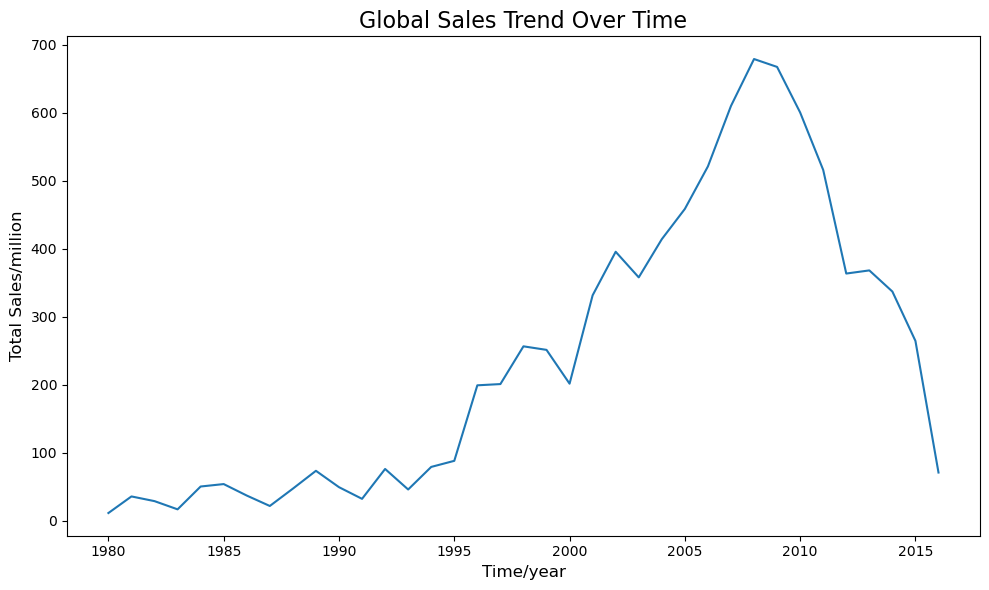

In [7]:
plt.figure(figsize=(10,6))
sns.lineplot(x=Global_Sales_Over_Time.index, y=Global_Sales_Over_Time.values, palette = 'viridis', legend = False)
plt.title('Global Sales Trend Over Time', fontsize=16)
plt.xlabel('Time/year', fontsize=12)
plt.ylabel('Total Sales/million', fontsize=12)
plt.tight_layout()
plt.show()


# What this chart shows
1980 - 1995 -> Gaming a slow and niche hobby with a small market.

1995 - 2000 -> PS 1 era, gaming introduced to mainstream audience.

2000 - 2008 -> Gaming has become fully mainstream with the introduction of various games.

2008 - 2009 -> Peak.

2009 - 2016 -> decline due to digital sales over physical.

2016 -> partial data of 2016.


# chart 3 
## Regional Sales by Genre (Heatmap)

In [8]:
genre_region = (df.pivot_table(index='Genre', 
               values=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'],
               aggfunc='sum'))
print(genre_region)

              EU_Sales  JP_Sales  NA_Sales  Other_Sales
Genre                                                  
Action          516.48    158.64    861.77       184.92
Adventure        63.74     51.99    101.93        16.70
Fighting        100.00     87.15    220.74        36.19
Misc            211.77    106.67    396.92        73.92
Platform        200.65    130.65    445.99        51.51
Puzzle           50.52     56.68    122.01        12.47
Racing          236.31     56.61    356.93        76.68
Role-Playing    187.57    350.25    326.50        59.38
Shooter         310.45     38.18    575.16       101.90
Simulation      113.02     63.54    181.51        31.34
Sports          371.34    134.76    670.09       132.65
Strategy         44.84     49.10     67.83        11.23


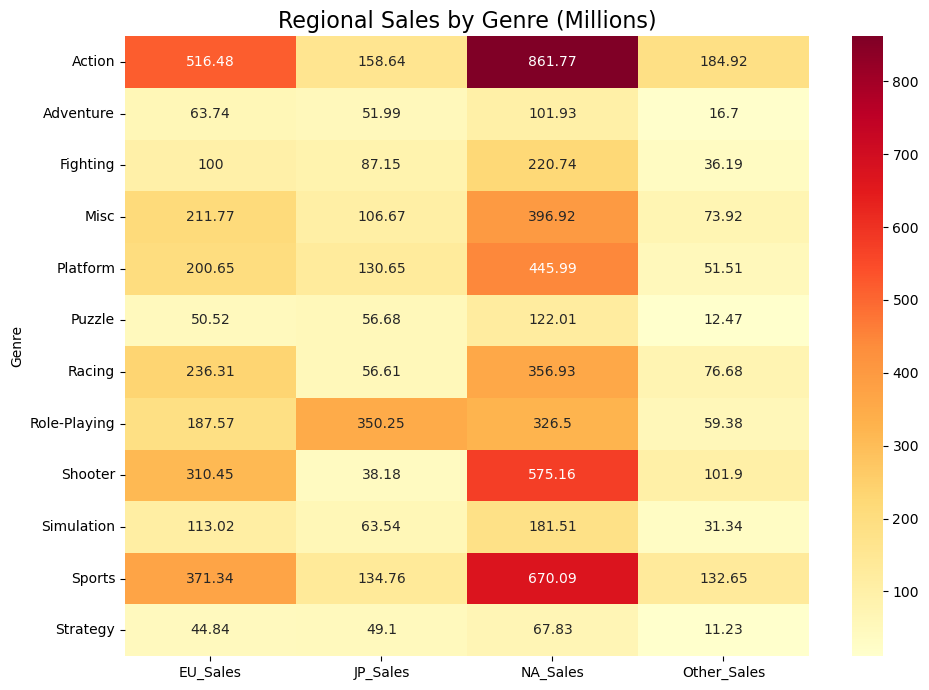

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(genre_region, annot=True, fmt='g', cmap='YlOrRd')
plt.title('Regional Sales by Genre (Millions)', fontsize=16)
plt.tight_layout()
plt.show()

### key insight
- The data of JP(Japan) shows the juxtaposition in taste profile with Western Profile which shows appreciation of Shooter and Sports games in NA reflecting sports culture of region.
- Japan's standout category being Role-Playing (350M) reflects a deep cultural appreciation for story-driven games ie. Final Fantas y and Dragon Quest.

# chart 4
## Top platforms by Total Sales

In [10]:
top_platforms = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print(top_platforms)


Platform
PS2     1233.46
X360     969.60
PS3      949.35
Wii      909.81
DS       818.62
PS       727.39
GBA      305.62
PSP      291.71
PS4      278.07
PC       254.70
Name: Global_Sales, dtype: float64


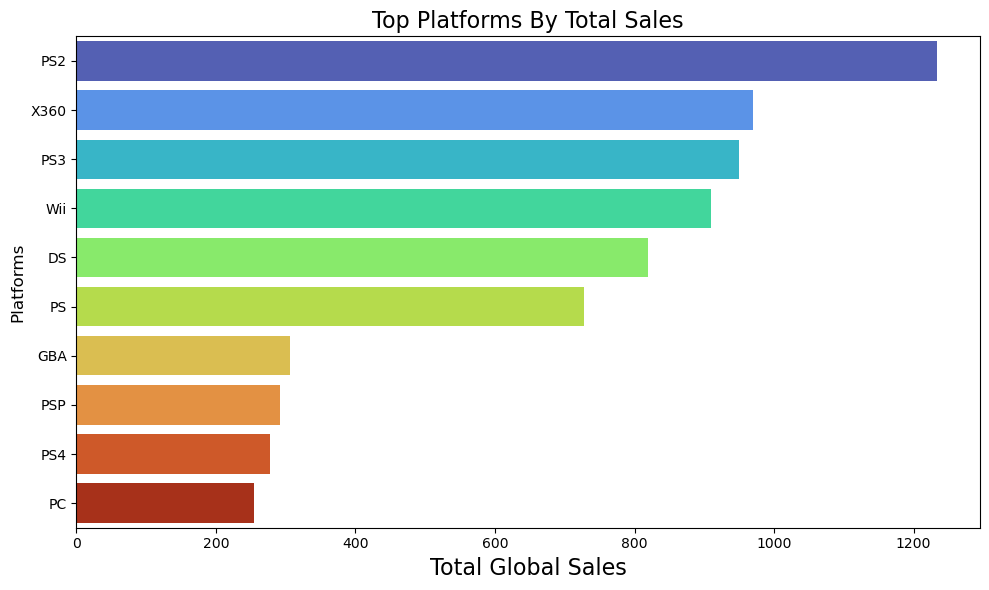

In [11]:
plt.figure(figsize=(10,6))
sns.barplot( x = top_platforms.values, y = top_platforms.index , palette = 'turbo' , legend = False)
plt.title('Top Platforms By Total Sales' , fontsize=16)
plt.xlabel('Total Global Sales', fontsize=16)
plt.ylabel('Platforms', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
na_eu_sales = df.groupby('Year')[['NA_Sales', 'EU_Sales' ]].sum()
print(na_eu_sales)

      NA_Sales  EU_Sales
Year                    
1980     10.59      0.67
1981     33.40      1.96
1982     26.92      1.65
1983      7.76      0.80
1984     33.28      2.10
1985     33.73      4.74
1986     12.50      2.84
1987      8.46      1.41
1988     23.87      6.59
1989     45.15      8.44
1990     25.46      7.63
1991     12.76      3.95
1992     33.87     11.71
1993     15.12      4.65
1994     28.15     14.88
1995     24.82     14.90
1996     86.76     47.26
1997     94.75     48.32
1998    128.36     66.90
1999    126.06     62.67
2000     94.49     52.75
2001    173.98     94.89
2002    216.19    109.74
2003    193.59    103.81
2004    218.80    105.92
2005    241.58    121.56
2006    263.12    129.24
2007    311.18    160.18
2008    351.44    184.40
2009    338.85    191.59
2010    304.24    176.57
2011    241.00    167.31
2012    154.93    118.76
2013    154.77    125.80
2014    131.97    125.63
2015    102.82     97.71
2016     22.66     26.76


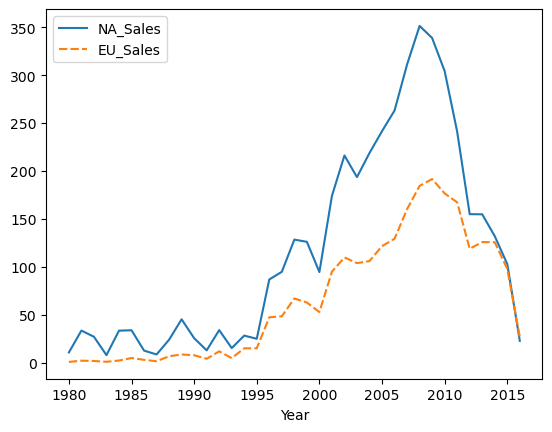

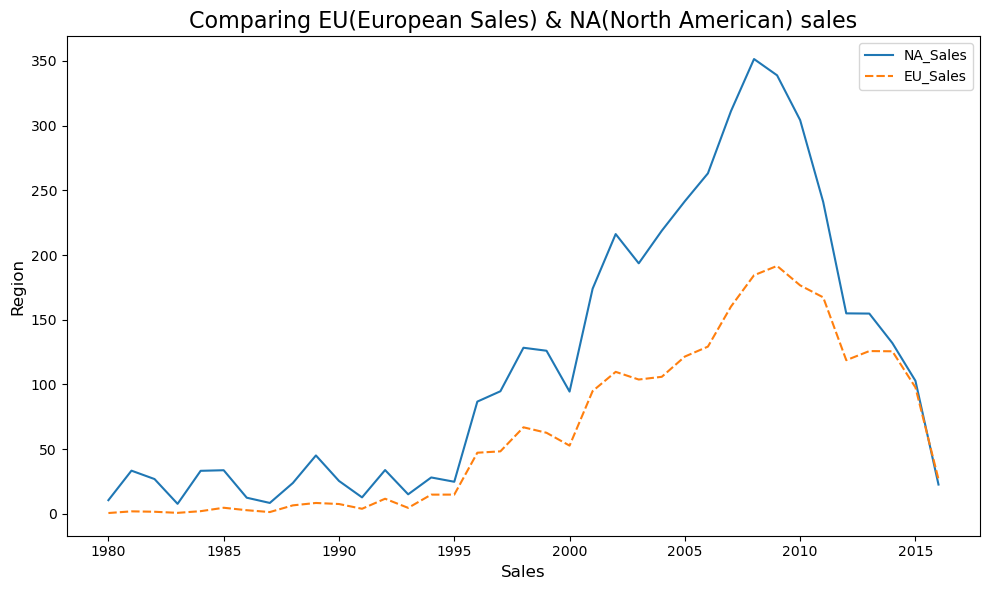

In [13]:
# melting concept via arg data
sns.lineplot(data=na_eu_sales)
'''
Seaborn will draw two columns and two lines and colors them differently
we'll pass the hold table and let Seaborn figure it out
'''
plt.figure(figsize=(10,6))
sns.lineplot(data=na_eu_sales)
plt.title('Comparing EU(European Sales) & NA(North American) sales', fontsize=16)
plt.xlabel('Sales' , fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()